In [27]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sklearn
import spacy
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
nlp = spacy.load("en_core_web_sm")

In [11]:
df = pd.read_csv('healthcare_dataset_dirty_5000_with_symptoms.csv')
print("Data types:\n", df.dtypes)

Data types:
 gender                   object
age                     float64
hypertension              int64
crohns_disease            int64
ever_married             object
work_type                object
Residence_type           object
avg_glucose_level       float64
bmi                     float64
smoking_status           object
symptoms_description     object
target                  float64
dtype: object


In [12]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 gender                  1233
age                        0
hypertension               0
crohns_disease             0
ever_married            1667
work_type                843
Residence_type          1689
avg_glucose_level          0
bmi                     2495
smoking_status          1022
symptoms_description     478
target                  1647
dtype: int64


In [13]:
df = df.dropna(subset=['target', 'symptoms_description'])  # essential columns

In [16]:
print("\nMissing values:\n", df.isnull().sum())
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df['Residence_type'] = df['Residence_type'].fillna(df['Residence_type'].mode()[0])


Missing values:
 gender                   751
age                        0
hypertension               0
crohns_disease             0
ever_married            1004
work_type                505
Residence_type          1003
avg_glucose_level          0
bmi                     1492
smoking_status           600
symptoms_description       0
target                     0
dtype: int64


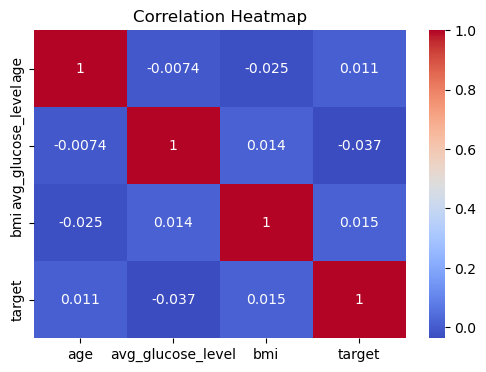

In [18]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
plt.figure(figsize=(6, 4))
sns.heatmap(df[numeric_cols + ['target']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [19]:
import string

stopwords_set = set([
    'a', 'an', 'the', 'and', 'or', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'have', 'has', 'had', 'do', 'does', 'did', 'of', 'on', 'in', 'to', 'from', 'by',
    'with', 'as', 'for', 'this', 'that', 'these', 'those', 'at', 'but', 'if', 'while'
])

In [20]:
def clean_text(text):
    text = text.lower().translate(str.maketrans('', '', string.punctuation))
    return ' '.join([word for word in text.split() if word not in stopwords_set])


In [21]:

df['clean_text'] = df['symptoms_description'].apply(clean_text)


In [23]:
!pip3 install wordcloud
from wordcloud import WordCloud

text_all = ' '.join(df['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_all)


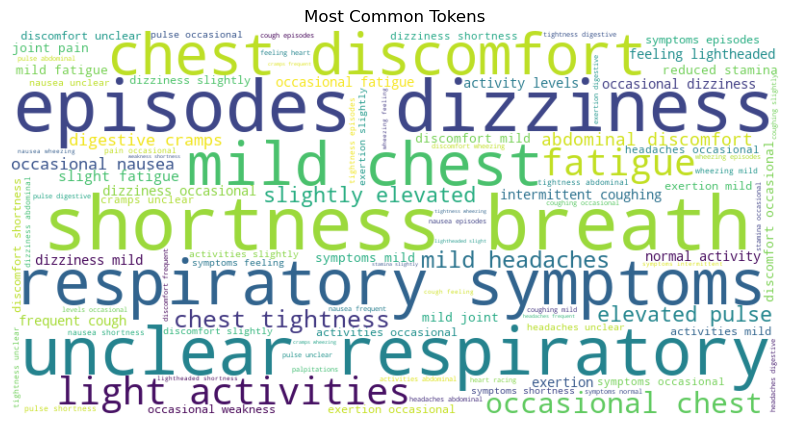

In [24]:
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Tokens")
plt.show()


In [25]:
vectorizer = TfidfVectorizer(max_features=300)
X_text = vectorizer.fit_transform(df['clean_text'])

# Select numeric features
from sklearn.preprocessing import StandardScaler
X_numeric = df[['age', 'avg_glucose_level', 'bmi']].values
X_numeric = StandardScaler().fit_transform(X_numeric)

# Combine text and numeric
import numpy as np
X = np.hstack([X_text.toarray(), X_numeric])
y = df['target'].astype(int)

# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


Accuracy: 0.5264900662251656
F1 Score: 0.5034722222222222

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.58      0.55       297
           1       0.54      0.47      0.50       307

    accuracy                           0.53       604
   macro avg       0.53      0.53      0.53       604
weighted avg       0.53      0.53      0.53       604



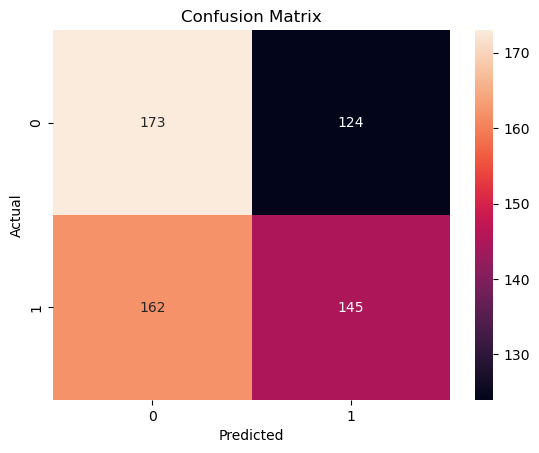

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [30]:
!pip3hf_dataset = Dataset.from_pandas(df[['clean_text', 'target']])
hf_dataset = hf_dataset.train_test_split(test_size=0.2)
 install datasets transformers torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

  Using cached datasets-3.6.0-py3-none-any.whl.metadata (19 kB)
  Using cached xxhash-3.5.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (12 kB)
  Using cached multiprocess-0.70.16-py312-none-any.whl.metadata (7.2 kB)
  Using cached tokenizers-0.21.1-cp39-abi3-macosx_11_0_arm64.whl.metadata (6.8 kB)
  Using cached safetensors-0.5.3-cp38-abi3-macosx_11_0_arm64.whl.metadata (3.8 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached hf_xet-1.1.3-cp37-abi3-macosx_11_0_arm64.whl.metadata (879 bytes)
Using cached datasets-3.6.0-py3-none-any.whl (491 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 10.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 MB 10.5 MB/s eta 0:00:0000:0100:01
Using cached multiprocess-0.70.16-py312-none-any.whl (146 kB)
Using cached safetensors-0.5.3-cp38-abi3-macosx_11_0_arm64.whl (418 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached tokenizers-0.21.1-cp39-abi3-macosx_11_0_arm64

In [31]:
hf_dataset = Dataset.from_pandas(df[['clean_text', 'target']])
hf_dataset = hf_dataset.train_test_split(test_size=0.2)


In [32]:
# Tokenize
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(batch):
    return tokenizer(batch['clean_text'], padding='max_length', truncation=True)

hf_dataset = hf_dataset.map(tokenize, batched=True)
hf_dataset = hf_dataset.remove_columns(['clean_text'])
hf_dataset.set_format('torch')

# Load model
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

# Trainer
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_dir='./logs',
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_dataset['train'],
    eval_dataset=hf_dataset['test'],
    tokenizer=tokenizer,
)

trainer.train()


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/2412 [00:00<?, ? examples/s]

Map:   0%|          | 0/604 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

{"timestamp":"2025-06-16T20:05:05.338520Z","level":"WARN","fields":{"message":"Reqwest(reqwest::Error { kind: Request, url: \"https://cas-server.xethub.hf.co/reconstruction/22f1240b5c3e6c4d5c19fe96c68b0600fca5743fba2460882dddac50aca607d8\", source: hyper_util::client::legacy::Error(Connect, ConnectError(\"tcp connect error\", Os { code: 60, kind: TimedOut, message: \"Operation timed out\" })) }). Retrying..."},"filename":"/Users/runner/work/xet-core/xet-core/cas_client/src/http_client.rs","line_number":200}
{"timestamp":"2025-06-16T20:05:05.338874Z","level":"WARN","fields":{"message":"Retry attempt #0. Sleeping 1.926686576s before the next attempt"},"filename":"/Users/runner/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/reqwest-retry-0.7.0/src/middleware.rs","line_number":171}
{"timestamp":"2025-06-16T20:15:07.389433Z","level":"WARN","fields":{"message":"Reqwest(reqwest::Error { kind: Request, url: \"https://cas-server.xethub.hf.co/reconstruction/22f1240b5c3e6c4d5c19fe96c68b0600

OSError: Can't load the model for 'distilbert-base-uncased'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure 'distilbert-base-uncased' is the correct path to a directory containing a file named pytorch_model.bin, tf_model.h5, model.ckpt or flax_model.msgpack.

In [ ]:
from peft import get_peft_model, LoraConfig, TaskType

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_lin", "v_lin"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_CLS
)

model_lora = get_peft_model(model, lora_config)
trainer.model = model_lora  # Replace Trainer model
trainer.train()


In [ ]:


preds = trainer.predict(hf_dataset['test'])
pred_labels = np.argmax(preds.predictions, axis=1)
true_labels = preds.label_ids

print("Accuracy:", accuracy_score(true_labels, pred_labels))
print("F1 Score:", f1_score(true_labels, pred_labels))
print("Report:\n", classification_report(true_labels, pred_labels))